In [1]:
%pip install -U duckduckgo-search langchain-community

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더한 결과를 반환합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱한 결과를 반환합니다."""
    return a * b

In [5]:
%pip install -U ddgs

Note: you may need to restart the kernel to use updated packages.


In [6]:
from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

/var/folders/8l/ylr41sxs3_l9cwqgdmznm12h0000gn/T/ipykernel_11466/2437116088.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults


In [7]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [8]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [9]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState):
    messages = list(state['messages'])
    summary = state.get('summary', '')
    # 오래된 메시지는 지워도 summary로 이전 맥락 유지
    if summary:
        messages = [SystemMessage(content=f'이전 대화 요약:\n{summary}')] + messages
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}


In [10]:
def summarize_message(state: AgentState):
    messages = state['messages']
    summary = state.get('summary', '')
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'

    if summary:
        summary_prompt = (
            'summarize this chat history below while looking at the summary of earlier conversations\n'
            f'chat_history:{messages}\n'
            f'summary:{summary}'
        )

    summary = llm.invoke(summary_prompt)
    return {'summary': summary.content}


In [11]:
from langchain_core.messages import RemoveMessage

def delete_message(state: AgentState):
    messages = state["messages"]
    delete_messages = [RemoveMessage(id=message.id) for message in messages]
    return {"messages": delete_messages}

In [12]:
from langgraph.graph import END

def should_continue(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    return 'summarize_message'

In [13]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(summarize_message)
graph_builder.add_node(delete_message)

In [14]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_message']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_message', 'delete_message')
graph_builder.add_edge('delete_message', END)

In [15]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer=checkpointer
)

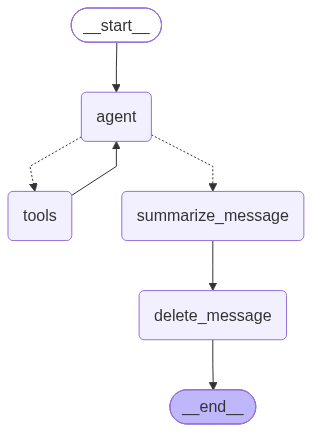

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary_v3'
    }
}

query = 'What currency is in Billy Giles\' birthplace?'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    if chunk.get('messages'):
        chunk['messages'][-1].pretty_print()


================================ Human Message =================================

What currency is in Billy Giles' birthplace?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_results_json (4d7acb62-f992-4e12-8028-e832c3f26436)
 Call ID: 4d7acb62-f992-4e12-8028-e832c3f26436
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_results_json

snippet: October 7, 2025 - Billy Giles (3 September 1957 – 25 September 1998) was an Ulster Volunteer Force volunteer who later became active in politics following his release from the Maze Prison in 1997 after serving 14 years of a life sentence for murder., title: Billy Giles - Wikipedia, link: https://en.wikipedia.org/wiki/Billy_Giles, snippet: February 5, 2026 - Giles is the son of Baseball Hall ... C. Giles, who was the general manager and president of the Cincinnati Reds (1937–1951) before becoming pres

In [18]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[]

In [19]:
graph.get_state(config).values['summary']

'The user asked for the currency in Billy Giles\' birthplace.\n\n1.  The AI first searched for "Billy Giles birthplace" and identified that Bill Giles (the meteorologist) was born in Dittisham, near Dartmouth, Devon, England.\n2.  Next, the AI searched for the "currency of England".\n3.  The search results indicated that the official currency of England (and the United Kingdom) is the Pound sterling (GBP).\n\nThe chat concludes with the AI stating that the currency in Bill Giles\' birthplace (Dittisham, England) is the Pound sterling (GBP).'

In [20]:
update_query = '출처 url을 포함해주세요. 한글로 답변해주세요.'
for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
    if chunk.get('messages'):
        chunk['messages'][-1].pretty_print()


================================ Human Message =================================

출처 url을 포함해주세요. 한글로 답변해주세요.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_results_json (b30c9c7f-6e1d-44cb-82a7-a0c9c2903b39)
 Call ID: b30c9c7f-6e1d-44cb-82a7-a0c9c2903b39
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_results_json

snippet: Billy Giles was an Ulster Volunteer Force volunteer who later became active in politics following his release from the Maze Prison in 1997 after serving 14 years of a life sentence for murder., title: Billy Giles - Wikipedia, link: https://en.wikipedia.org/wiki/Billy_Giles, snippet: View the 2016-17 NCAAM season full splits for Billy Giles of the Robert Morris Colonials on ESPN. Includes full stats per opponent, and home and away games., title: Billy Giles 2016-17 NCAAM Splits - ESPN, link: https://www.espn.com/mens-

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 14.112316338s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
current_message_list = graph.get_state(config).values['messages']
current_message_list